In [1]:
import numpy as np
import pickle
import pandas as pd
import scipy as sp
import scipy.stats as stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib

from _helper_functions import cb
from _helper_functions import zipdf


import _helper_grammar_functions as jsgo

In [2]:
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF=pd.read_pickle(fn).set_index('wt-enhancer-seq')
allDF.head(1)

,enhancer-id,enhancer-sites,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0


In [3]:
## set hypergenometic null distribution

## frist remove all variants not dependent on gata and ets

# what are all active variants?
activityCol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
confidentPos=1
confidentNeg=0

active_seqs_all_gataets       = set(allDF.loc[allDF[activityCol]>=confidentPos,       :].index)
active_seqs_dependent_gataets = set(allDF.loc[allDF['enhancer-dependent-gata-ets']==1,:].index)

# what active variants not dependent on gata and ets
active_seqs_independent_gataets = active_seqs_all_gataets - active_seqs_dependent_gataets

# remove active variants not dependent on gata and ets
desired_seqs = set(allDF.index) - active_seqs_independent_gataets

# subset
allDF=allDF.loc[list(desired_seqs),:]
len(allDF)

431974

In [4]:
M      = len(allDF)                             # total number of objects            (ie total number enhancers)
n_func = sum(allDF[activityCol]>confidentPos)   # total number of type i objects     (ie total number of func ens)
n_nfun = sum(allDF[activityCol]<confidentNeg)   # total number of type i objects     (ie total number of nonfunc ens)

M,n_func,n_nfun

(431974, 52139, 143799)

In [5]:
mDF_fn='F05-Syntax-Features/5-stats-sig-motifs-possible-realData_filtMotifs=ord_ori_spc_minenrichFUNC=0.1_minN=50.pandas.df.pickle'
mDF=pd.read_pickle(mDF_fn)

mDF.head(1)

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(63, 34, 7)",1.042766e-32,5.018826,11.206427,3.246130e-29


In [6]:
jsgo.motif_revcomp_with_phrasetype('ord_ori_spc=g_21_e_24_E')

'ord_ori_spc=e_24_E_21_G'

In [7]:
allSigMotifs=set()

for mi in mDF.index:
    allSigMotifs.add(mi)
    allSigMotifs.add(jsgo.motif_revcomp_with_phrasetype(mi))

In [8]:
with open('F05-Syntax-Features/Length2Phrase2ActList.pydict.pickle','rb') as f:
    Length2Phrase2ActList=pickle.load(f)

In [9]:
with open('F05-Syntax-Features//MotifGraph.without_parse_.pydict.pickle','rb') as f:
    MotifGraph=pickle.load(f)

In [17]:
fnrealAll='F05-Syntax-Features/2-all-phrases-possible-withRealData-50k.pd.df.pickle'

dfAll=pd.read_pickle(fnrealAll)
dfAll['phrase-type']=dfAll['phrase-type'].apply(lambda s: s.replace("parse_",''))
dfAll['phrase-key']=dfAll['phrase'].apply(lambda s: '_'.join([str(si) for si in s]))

dfAll['phrase-key-unique']=dfAll.apply(lambda row: row['phrase-type']+'='+row['phrase-key'],axis=1)

dfAll=dfAll.set_index('phrase-key-unique')
dfAll.head(1)


,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,phrase-key
phrase-key-unique,,,,,,
ord_ori_spc=E_24_E,"(E, 24, E)",ord_ori_spc,2,True,"(297, 1183, 669)",E_24_E


# A function to impute 2-mer syntax features

In [18]:
strengthCol='func-odds-ratio'

In [19]:
cols=[
    'phrase-key',
    'phrase-length',
    'func-odds-ratio',
    'real-data',
    'hyp-func-p-bonf'
]
spcDF=mDF.reset_index().loc[:,cols]
spcDF['num-total-seqs']=spcDF['real-data'].apply(lambda tup: sum(tup))
spcDF['num-active-ens']=spcDF['real-data'].apply(lambda tup: tup[0])
spcDF['obs-or-imputed']='obs'
spcDF.head()

,phrase-key,phrase-length,func-odds-ratio,real-data,hyp-func-p-bonf,num-total-seqs,num-active-ens,obs-or-imputed
0,ord_ori_spc=g_21_e_24_E,3,11.206427,"(63, 34, 7)",3.246130e-29,104,63,obs
1,ord_ori_spc=g_13_e_24_E,3,8.385350,"(108, 73, 21)",3.208155e-43,202,108,obs
2,ord_ori_spc=g_36_g_9_E,3,7.889255,"(162, 108, 42)",8.148688e-63,312,162,obs
3,ord_ori_spc=g_15_E_22_E,3,7.098879,"(107, 85, 25)",2.072536e-38,217,107,obs
4,ord_ori_spc=e_24_E_8_G,3,7.029848,"(105, 80, 29)",2.031084e-37,214,105,obs


In [20]:
def get_imputed_spacings(pdSeries):
    # linear interpolation
    x2height={xi:hi for xi,hi in zip(pdSeries.index,pdSeries)}
    
    rangeX=range(min(pdSeries.index),max(pdSeries.index)+1)
    heightsPlottedForSeries=[x2height[xi] if xi in x2height else np.NaN for xi in rangeX ]

    
    spcDF=pd.Series(heightsPlottedForSeries,index=rangeX)
    imputeDF=spcDF.interpolate()
        
    spcObserved=set(pdSeries.index)
    
    spcImputed=set(rangeX)-spcObserved
    
    return imputeDF,imputeDF[list(spcImputed)],imputeDF[list(spcObserved)]
    

In [21]:
def effect_curve(x,a,b,c,d):
    return c * np.sqrt(a*x+b) + d

In [22]:
numInertTotal=sum(allDF['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<0)
numInertTotal

143799

# Periodicity and syntax feature imputation

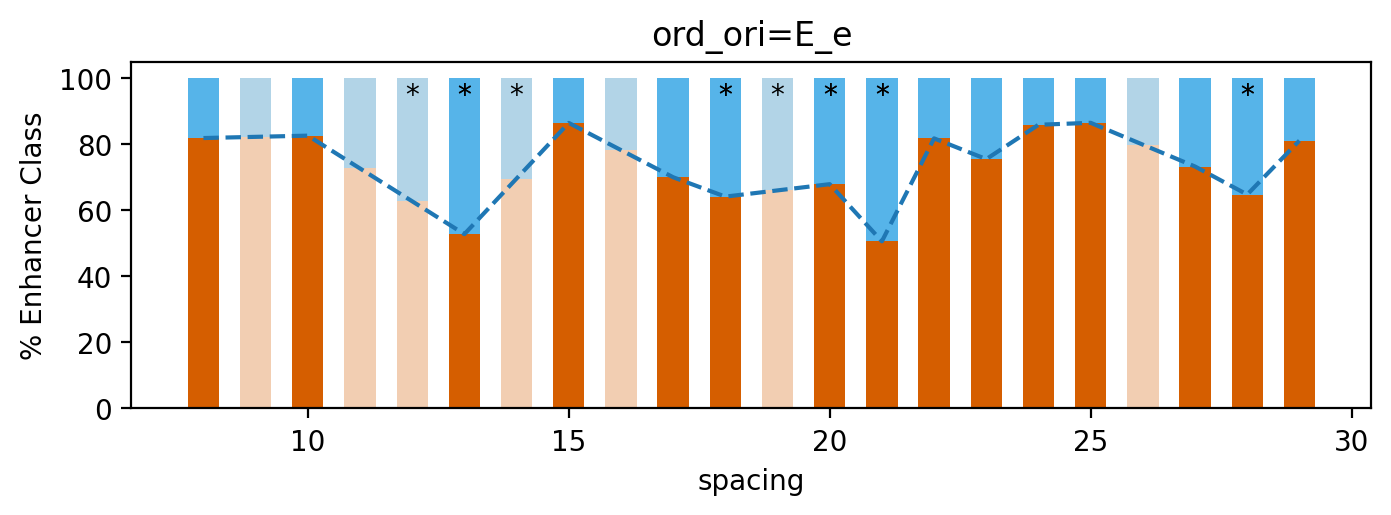

In [23]:
numTestsPerformed=5440

def get_missing_spacing_data_2mer(ordOriMotif,MotifGraph,spcMax,graphSpacingModel,graphEffectModel,savefigs,appendSpcDF=False):
    
    phraseLen=2
    
    global spcDF
    global dfAll
    
    ordOriSpcObservedMotifs=MotifGraph[ordOriMotif]['spc']            
    
    ########################################################################
    # Get all phrases which exist
    ########################################################################
    
    if graphSpacingModel:
        fig,ax=plt.subplots(1,figsize=(8,2.25),dpi=200)
        
    # Check to see which spacicng are present in dicitonary
    phrasesToPlot=[]
    phrasesSeen=set()
    phrasesUnseen=set()
    for spci in range(7,spcMax):

        title='ord_ori_spc'
        t1,t2=ordOriMotif.split('=')[-1].split('_')
        phraseStr=f'{t1}_{spci}_{t2}'
        phraseKey=jsgo.get_phrase_key(phraseStr)
        phraseKeyRc=jsgo.get_phrase_key(jsgo.motif_revcomp_with_phrasetype(f'{title}={phraseStr}').split('=')[-1])

        if phraseKey in Length2Phrase2ActList[phraseLen]:
            phrasesToPlot.append((True,phraseStr,phraseKey,title,phraseLen,spci)) 
            phrasesSeen.add(phraseStr)
        
        elif phraseKeyRc in Length2Phrase2ActList[phraseLen]:
            phrasesToPlot.append((True,phraseStr,phraseKeyRc,title,phraseLen,spci)) 
            phrasesSeen.add(phraseStr)

        else: 
            phrasesUnseen.add(phraseStr)

    heightsPlotted=[]
    percentSeqsWithMotifThatAreActive=[]
    spacingsPlotted=[]
    effectSizePlotted=[]
    effectSizeSpacingPlotted=[]
    spc2effect={}
    spc2sig={}
    for xi,(spacing,phrase,phraseKey,title,phraseLength,spci) in enumerate(phrasesToPlot):

        mi='ord_ori_spc='+phrase
        title=title.replace('parse_','')
        mi=f'{title}={phrase}'
        
        if mi not in dfAll.index:
            mi=jsgo.motif_revcomp_with_phrasetype(mi)

        FU,UN,NF=dfAll.at[mi,'real-data']
        
        if mi in mDF.index:
            pval=mDF.at[mi,'hyp-func-p-bonf']
            sig=pval<.05
            
        else:
            sig=0
        
        spc2sig[spci]=sig
        
        N=sum([FU,NF])

        # if plotOnXBySpacing:
        xi=spci

        bottom=0
        for bi,(height,color) in enumerate([(FU,cb['lightblue']),(NF,cb['red'])][::-1]):

            height=100*height/N
                
            if graphSpacingModel:
                if mi in allSigMotifs:
                    ax.text(xi,95,'*',ha='center',va='center')
                ax.bar(x=xi,height=height,bottom=bottom,color=color,width=.6)
                bottom+=height

        percentSeqsWithMotifThatAreActive.append(100*FU/(FU+UN+NF))
        heightsPlotted.append(100*FU/N)
        spacingsPlotted.append(spci)
        
        # if motif (and revcomp) not in DF
        if (mi not in mDF.index) and (jsgo.motif_revcomp_with_phrasetype(mi) not in mDF.index):
            pass
        
        else:
            effectSize=mDF.at[mi,strengthCol]
            effectSizePlotted.append(effectSize)
            effectSizeSpacingPlotted.append(spci)
            spc2effect[spci]=effectSize
        
    ########################################################################
    # Get predictor of % enrichment in func enhancers
    ########################################################################
     
    # Get all tbc observed
    spcObs=spacingsPlotted

    # get percent func
    spcObsSeries_forplot=pd.Series(heightsPlotted,index=spacingsPlotted)
    spcObsSeries_forstats=pd.Series(percentSeqsWithMotifThatAreActive,index=spacingsPlotted)

    # get imputed values
    allSpcDF_forplot,imputeDF,obsDF=get_imputed_spacings(spcObsSeries_forplot)
    allSpcDF_forstats,_,_          =get_imputed_spacings(spcObsSeries_forstats)
    
    if graphSpacingModel:
        x=list(range(min(spacingsPlotted),max(spacingsPlotted)+1))
        ax.plot(x,[100-xi for xi in allSpcDF_forplot[x]],'--')    
        ax.set_ylabel('% Enhancer Class')
        ax.set_xlabel('spacing')
        ax.set_title(ordOriMotif)

    
    ########################################################################
    # Get predictor for effectsize
    ########################################################################

    spacingShared=[i for i in obsDF.index if i in spc2effect]
    x=[obsDF[i] for i in spacingShared]
    y=[spc2effect [spci] for spci in spacingShared ]
    
    sig2color={True:cb['blue'],False:cb['red']}
    colors=[sig2color[spc2sig[spci]] for spci in spacingShared ]


    # sort list by x
    x, y = zip(*sorted(zip(x, y)))    
    poly=1
    z=np.polyfit(x,y,poly)
    minPercentFunctional=min(y)
    
    ########################################################################
    # Impute if spacing is func and effect size 
    ########################################################################
        
    impPercent=[]
    impEffect =[]
    impLabel  =[]
    
    outcols=[\
     'phrase-key'     ,
     'phrase-length'  ,
     'func-odds-ratio',
     'hyp-func-p-bonf',
     'num-total-seqs' ,
     'num-active-ens' ,
     'obs-or-imputed' ,
     'real-data'
    ]
    
    c2v={c:[] for c in outcols}
    
    spc2averagespace={}
    for mi in phrasesUnseen:        
        t1,spc,t2=mi.split('_')
        spc=int(spc)
        
        sampleSizes=[]
        
        # get sample size for the nearest 2 motifs
        for direction in [+1,-1]:
            
            for bp in range(1,10):
                bp=bp*direction+spc
                seenMotif=f'ord_ori_spc={t1}_{bp}_{t2}'
                
                if seenMotif in dfAll.index:
                    allCounts=dfAll.at[seenMotif,'real-data']
                    sampleSizes.append(sum(allCounts))        
                    break
                    
                elif jsgo.motif_revcomp_with_phrasetype(seenMotif) in dfAll.index:
                    allCounts=dfAll.at[jsgo.motif_revcomp_with_phrasetype(seenMotif),'real-data']
                    sampleSizes.append(sum(allCounts))        
                    break
        
        
        avgSampleSizeOfNearMotifs=sum(sampleSizes)/len(sampleSizes)        
        spc2averagespace[spc]=avgSampleSizeOfNearMotifs
        
        # predict percent enrichment
        if spc in allSpcDF_forplot:
            percent_forplot=allSpcDF_forplot[spc]
            
            if graphSpacingModel:
                ax.bar(x=spc,height=100-percent_forplot,bottom=0,color=cb['red'],alpha=.3,width=.6)
                ax.bar(x=spc,height=percent_forplot,bottom=100-percent_forplot,color=cb['blue'],alpha=.3,width=.6)

                
            # predict p value
            
            # Recall that...
            #    n = total number functional enhancers in lib dependent on gata/ets
            #    M = total number sequences in lib 
            #    N = number sequences with motif 
            #    k = number functional enhancers with motif

            percent_forstats=allSpcDF_forstats[spc]
            percent_forstats=percent_forstats/100 # 
            avgSampleSizeOfNearMotifs=int(spc2averagespace[spc])

            # if sample size too small, skip
            if avgSampleSizeOfNearMotifs<50: continue
                
            k_func=int(avgSampleSizeOfNearMotifs*percent_forstats)
            
            pval=stats.hypergeom.sf(k=k_func, M=M, n=n_func, N=avgSampleSizeOfNearMotifs)
            pval=min(1,5440*pval) # number of tests performed for observed motifs            
            enrichmentPercentMeasurement= (k_func/avgSampleSizeOfNearMotifs) / (n_func/M)

            # calculate odds ratio
            Fm = k_func # seqs with motif that are func
            num_Fm_and_Nm = Fm/(percent_forplot/100)
            Nm = num_Fm_and_Nm-Fm # seqs with motif that are inert
            Fn = n_func - Fm # seqs without motiif func
            Nn = numInertTotal - Nm # seqs without motiif inert

            Um=avgSampleSizeOfNearMotifs-Fm-Nm

            oddsratio = (Fm/Nm) / (Fn/Nn)

            # see if effect is sufficient to be significant accourding to the observed motifs
            if enrichmentPercentMeasurement>1.1 and pval<.05:

                # write this motif out
                c2v['phrase-key'].append(f'ord_ori_spc={mi}')
                c2v['phrase-length'].append(phraseLen)
                c2v['func-odds-ratio'].append(oddsratio)
                c2v['obs-or-imputed'].append('imp')
                c2v['hyp-func-p-bonf'].append(min(1,numTestsPerformed*pval))
                c2v['num-total-seqs' ].append(avgSampleSizeOfNearMotifs)
                c2v['num-active-ens' ].append(k_func)
                c2v['real-data' ].append((round(Fm),round(Um),round(Nm)))

                impPercent.append(100*percent_forstats)
                impLabel.append(mi)

                ax.text(spc,95,'*',ha='center',va='center')
            
    if appendSpcDF:
        spcDF=pd.concat([spcDF,pd.DataFrame(c2v)])
    
    if graphSpacingModel:
        ax.set_xlabel("spacing")
        if savefigs:
            label=ordOriMotif.split('=')[-1]
            plt.savefig(f'000-manuscript-figs/06d_MOT_20230919_Syntax-Motif-Fill-Spacing-and-periodicity__spc-{label}.svg',bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

            
get_missing_spacing_data_2mer('ord_ori=E_e',
                         MotifGraph,
                         spcMax=30,
                         graphSpacingModel=True,
                         graphEffectModel=True,
                         savefigs=False)

# Apply functions to all motifs

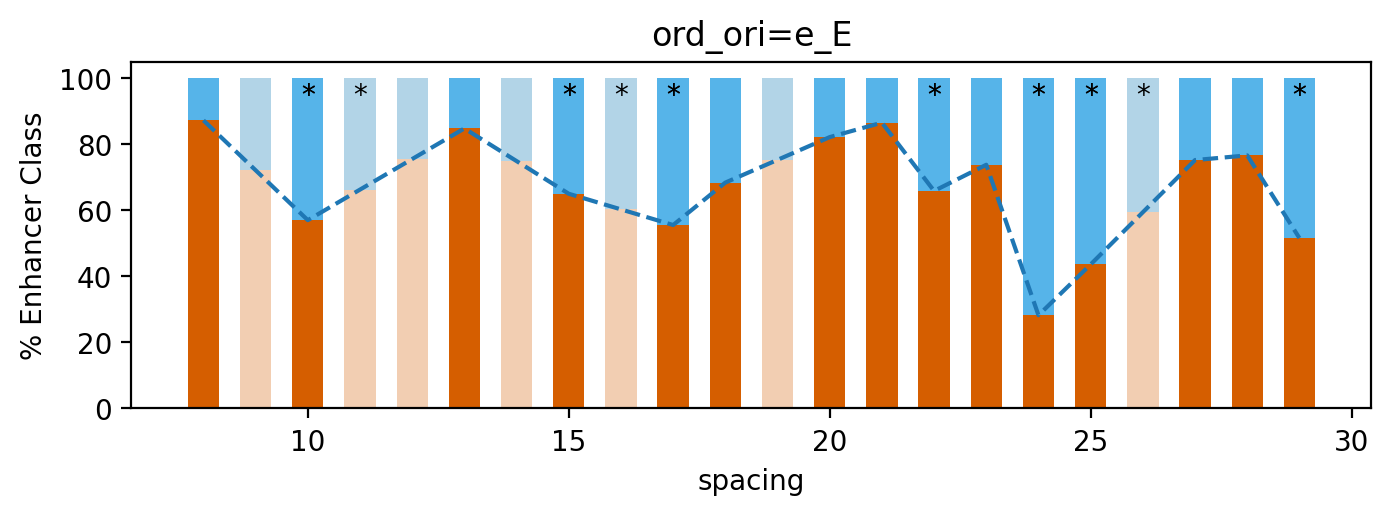

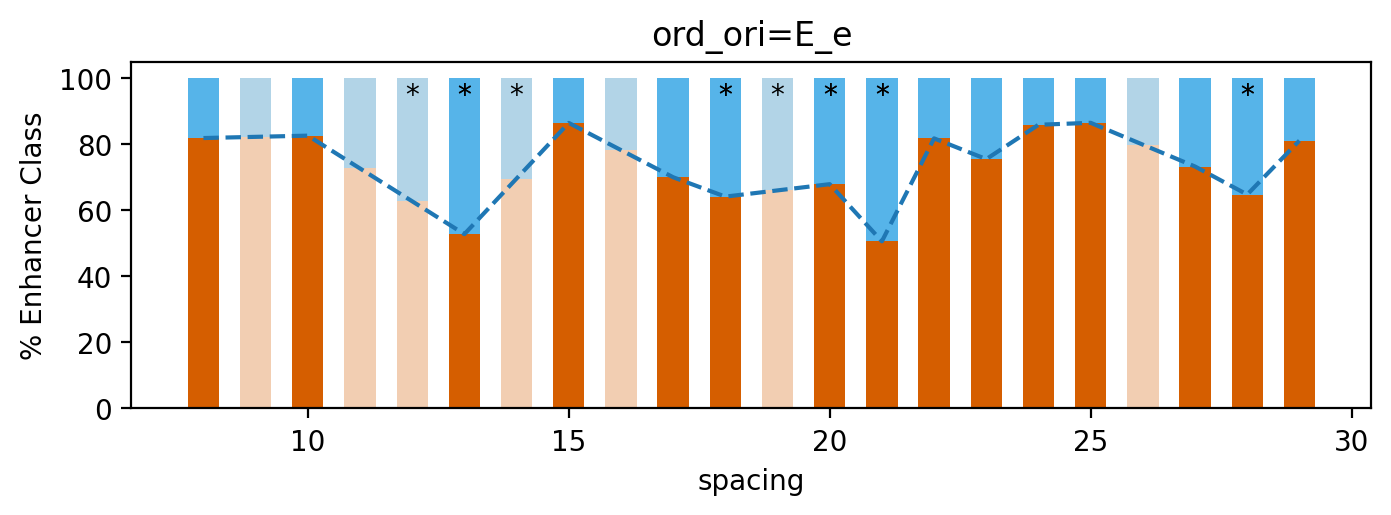

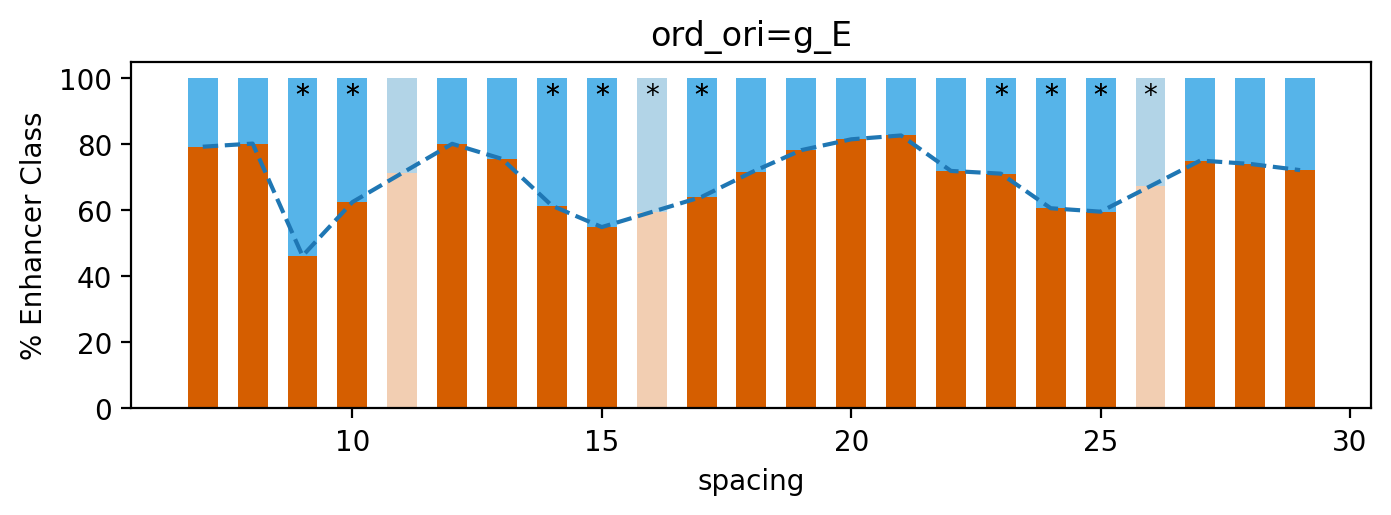

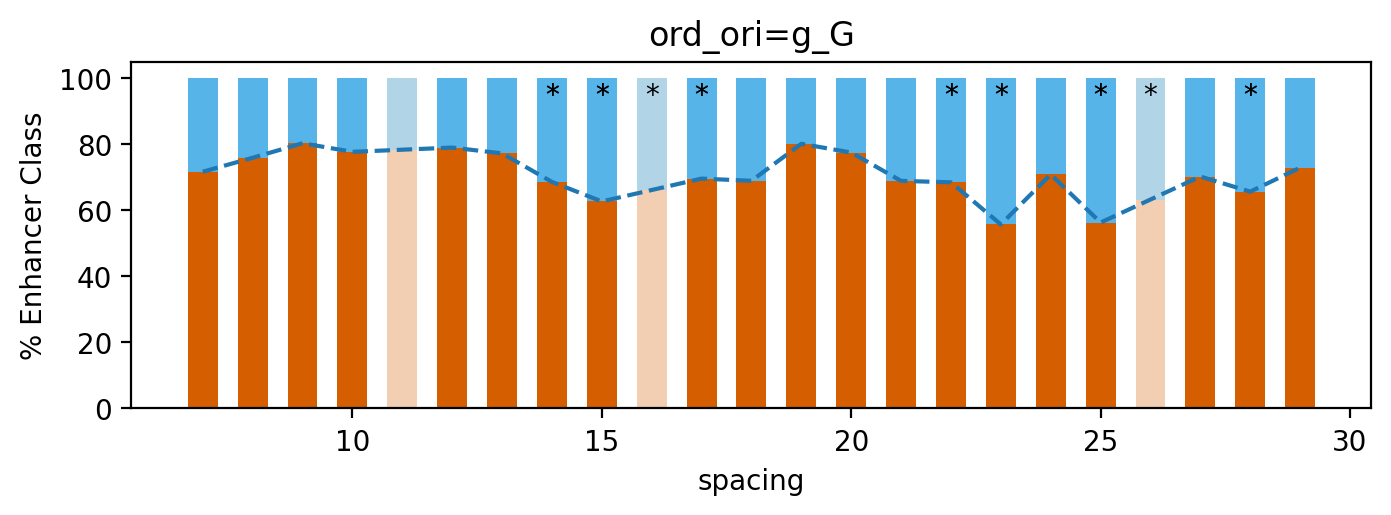

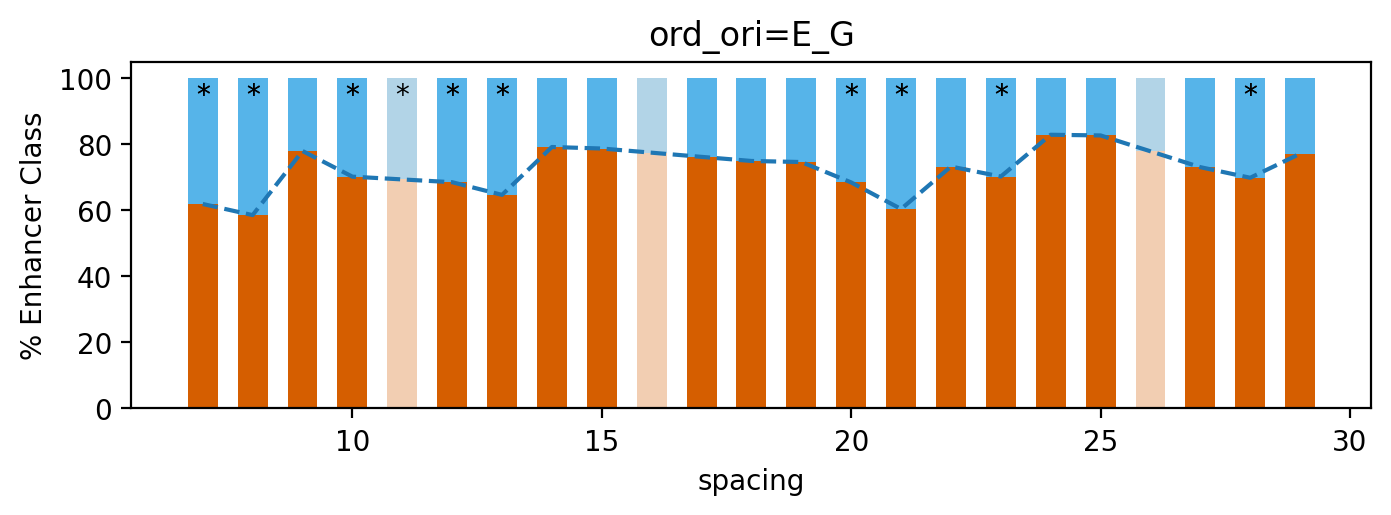

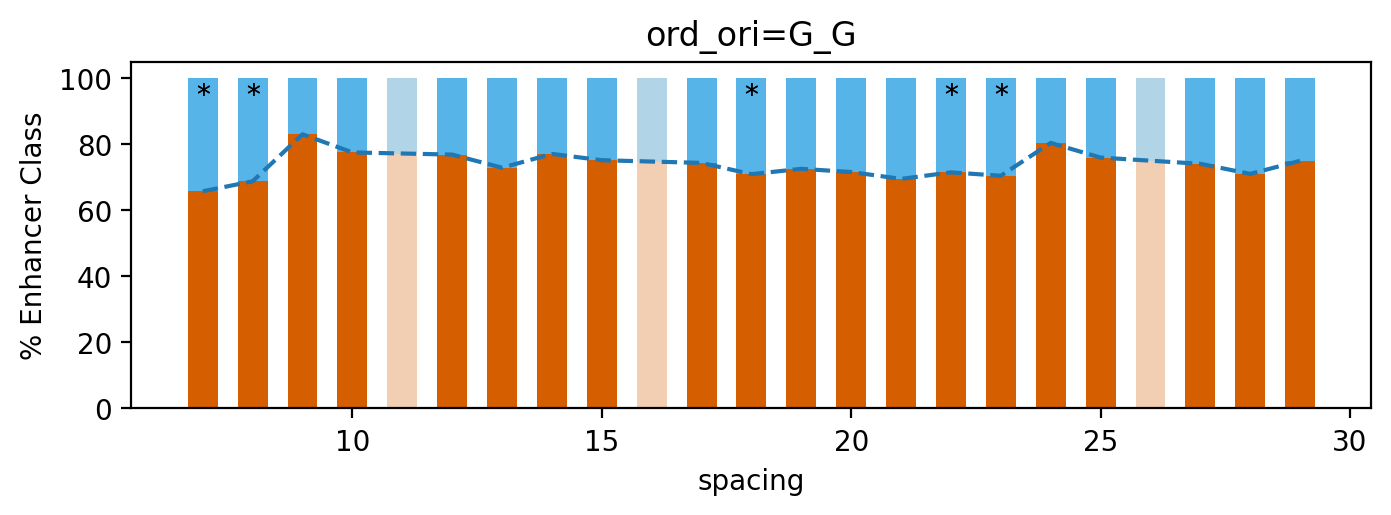

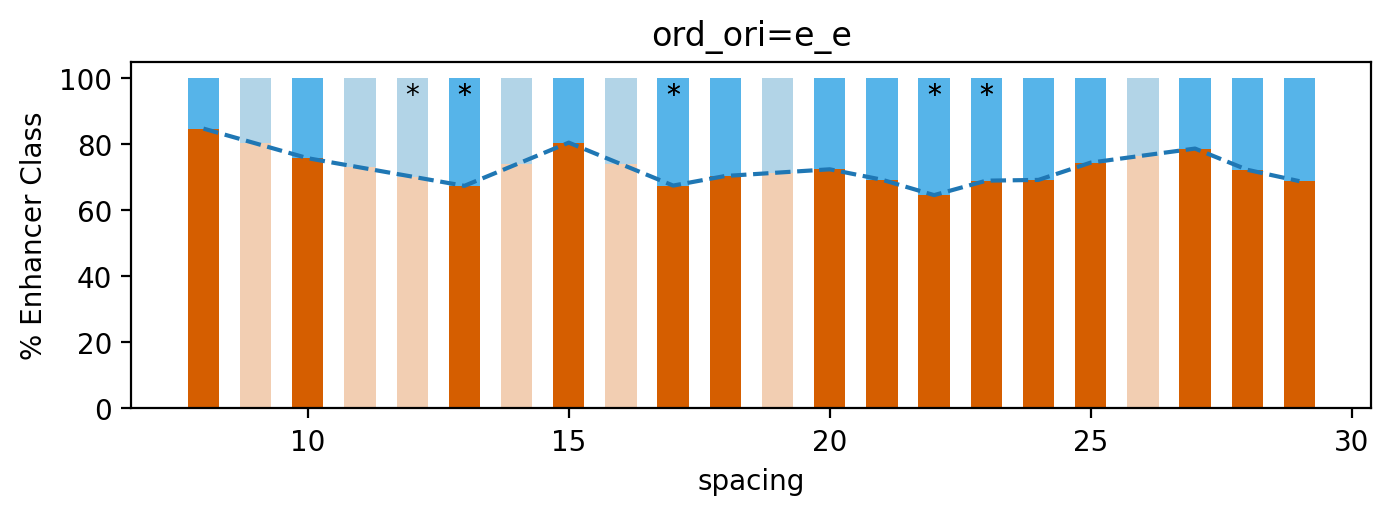

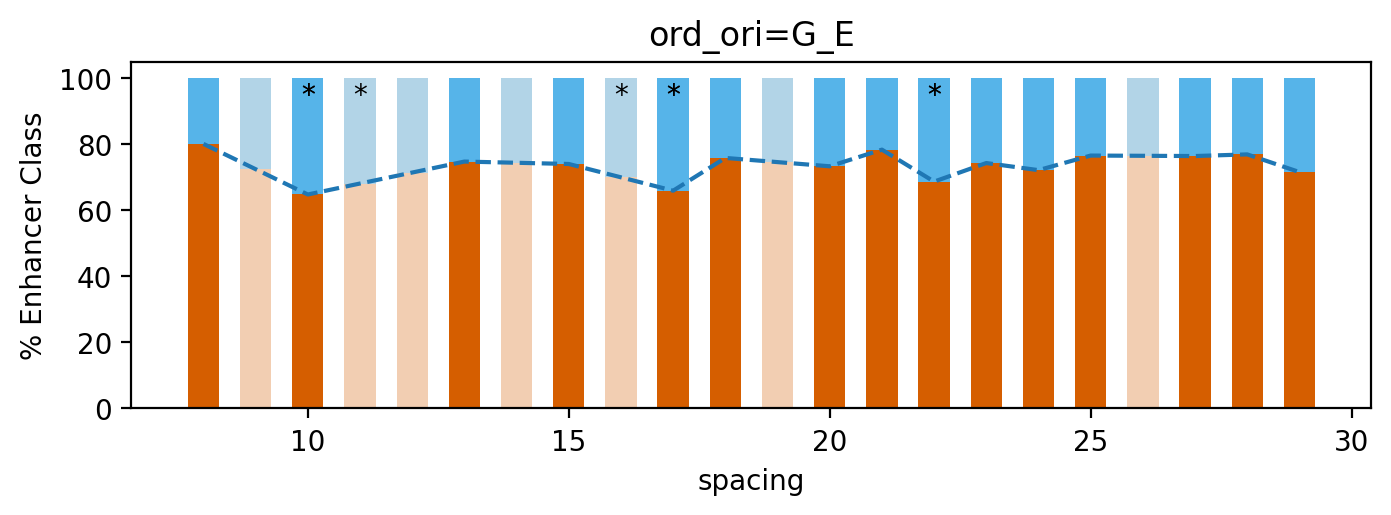

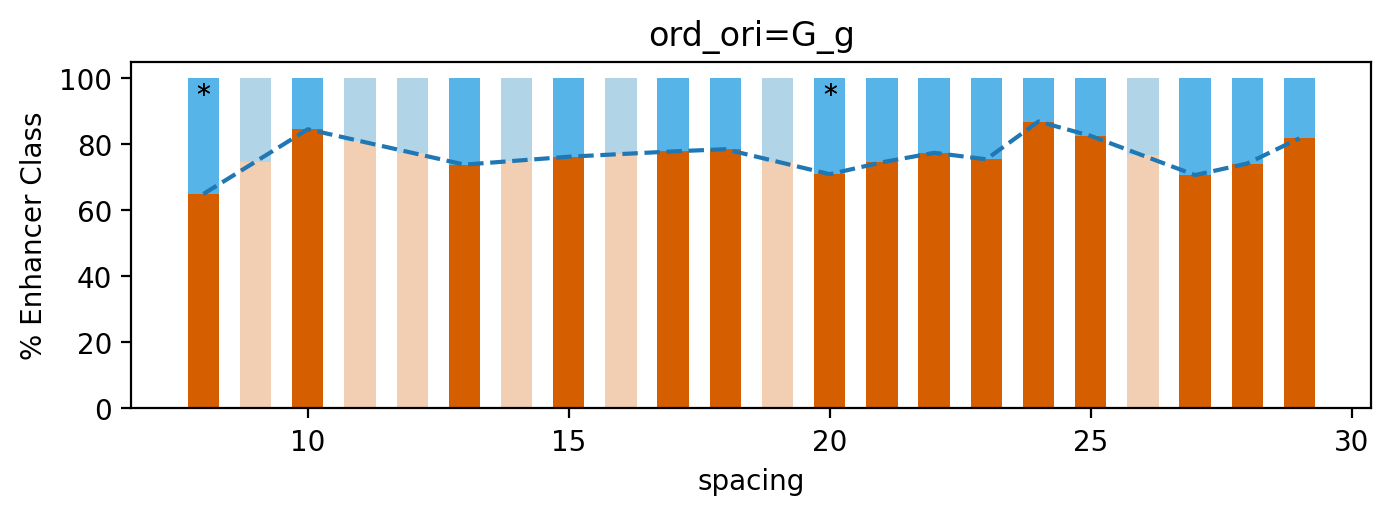

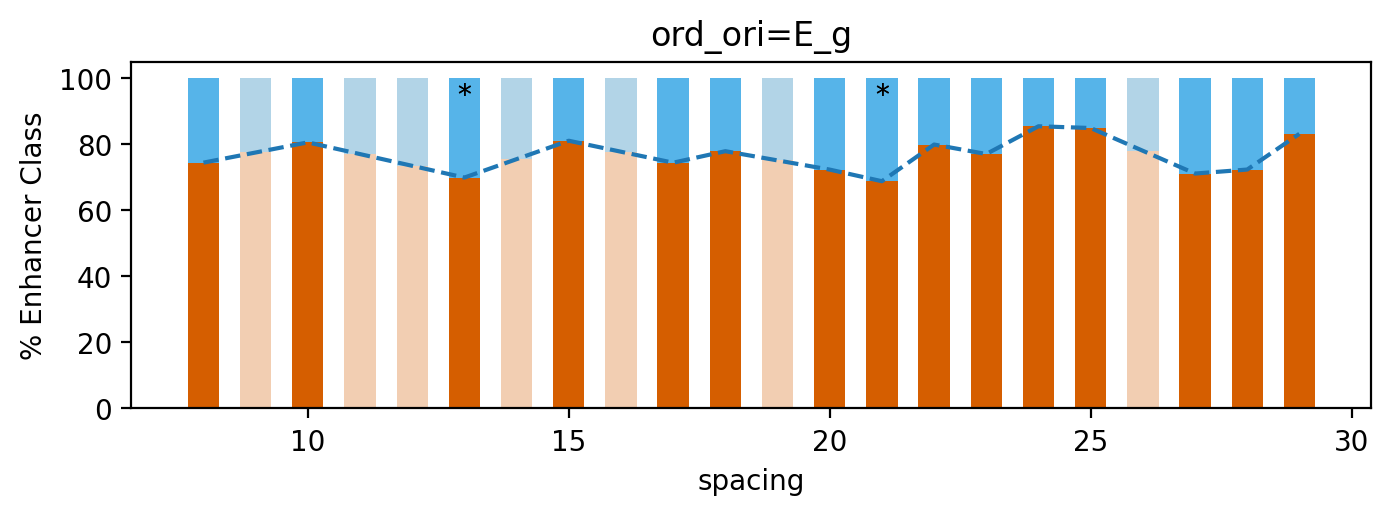

In [24]:
ordOriMotifsAnalyzed=set()
for i,(phraseKey,phraseLen,oddsRatio) in enumerate(zipdf(spcDF,['phrase-key','phrase-length','func-odds-ratio'])):

    if phraseKey not in MotifGraph: continue
    if '-spc' not in MotifGraph[phraseKey]: continue
    ordOriMotifSet=MotifGraph[phraseKey]['-spc']
    
    if phraseLen==3: continue
    
    for ordOriMotif in ordOriMotifSet:
        if (ordOriMotif in ordOriMotifsAnalyzed) or (jsgo.motif_revcomp_with_phrasetype(ordOriMotif) in ordOriMotifsAnalyzed):
            continue
            
        else:            
            if phraseLen==2:
                get_missing_spacing_data_2mer(ordOriMotif,
                                               MotifGraph,
                                               spcMax=30,
                                               graphSpacingModel=True,
                                               graphEffectModel=False,
                                               savefigs=False,
                                               appendSpcDF=True)
                                
            else:
                raise ValueError('incorrect num tfbs')
                
            ordOriMotifsAnalyzed.add(ordOriMotif)
            ordOriMotifsAnalyzed.add(jsgo.motif_revcomp_with_phrasetype(ordOriMotif))
            

# Output Supplemental Table

In [25]:
spcDF=spcDF.set_index('phrase-key')
spcDF.head()

,phrase-length,func-odds-ratio,real-data,hyp-func-p-bonf,num-total-seqs,num-active-ens,obs-or-imputed
phrase-key,,,,,,,
ord_ori_spc=g_21_e_24_E,3.0,11.206427,"(63, 34, 7)",3.246130e-29,104.0,63.0,obs
ord_ori_spc=g_13_e_24_E,3.0,8.385350,"(108, 73, 21)",3.208155e-43,202.0,108.0,obs
ord_ori_spc=g_36_g_9_E,3.0,7.889255,"(162, 108, 42)",8.148688e-63,312.0,162.0,obs
ord_ori_spc=g_15_E_22_E,3.0,7.098879,"(107, 85, 25)",2.072536e-38,217.0,107.0,obs
ord_ori_spc=e_24_E_8_G,3.0,7.029848,"(105, 80, 29)",2.031084e-37,214.0,105.0,obs


In [26]:
spcDF.to_pickle('F05-Syntax-Features/6-real-and-imputed-motifs.pd.df.pickle')
spcDF.to_csv('F05-Syntax-Features/6-real-and-imputed-motifs.tsv',sep='\t')